# 01 — Análisis exploratorio del problema de clasificación


## 1. Propósito del notebook

Este notebook tiene como objetivo comprender el problema y el dataset antes de definir formalmente el pipeline de Machine Learning.

En esta etapa queremos responder preguntas como:

* ¿Qué problema queremos resolver?
* ¿Qué representan las observaciones?
* ¿Cuántas variables existen?
* ¿Cuál es la variable objetivo?
* ¿Qué tipos de variables tenemos?
* ¿Existen valores faltantes?
* ¿Existen duplicados?
* ¿Cómo están distribuidas las clases?
* ¿Las features trabajan en escalas similares?
* ¿Existen correlaciones fuertes?
* ¿Qué decisiones iniciales de modelado parecen razonables?

# 2. Relación con el pipeline MLOps

La responsabilidad de este notebook es distinta de la del pipeline oficial.

La arquitectura actual reserva `notebooks/` para EDA y prototipado.

# 3. Preparación del entorno

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definimos rutas relativas al módulo `ml/`.

NOTEBOOK_DIR = Path.cwd()

# Permite ejecutar el notebook tanto desde ml/notebooks/
# como desde otros entornos habituales.
if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
else:
    ML_ROOT = NOTEBOOK_DIR

DATA_PATH = ML_ROOT / "data" / "raw" / "dataset.csv"

print(f"ML root: {ML_ROOT}")
print(f"Dataset: {DATA_PATH}")

ML root: /home/jorge/Descargas/mlops/micro-proyecto/Microproyecto/ml
Dataset: /home/jorge/Descargas/mlops/micro-proyecto/Microproyecto/ml/data/raw/dataset.csv


# 4. Carga del dataset

In [2]:
# data/raw/dataset.csv

df = pd.read_csv(DATA_PATH)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 5. Dimensiones generales

In [3]:
rows, columns = df.shape

print(f"Observaciones: {rows}")
print(f"Columnas totales: {columns}")

Observaciones: 569
Columnas totales: 31


# 6. Identificación de X e y


In [4]:
TARGET = "target"

X = df.drop(columns=TARGET)
y = df[TARGET]

print("X:", X.shape)
print("y:", y.shape)

X: (569, 30)
y: (569,)


# 7. Tipos de variables

In [7]:
# df.dtypes
print(df.dtypes.value_counts())
non_numeric_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Features no numéricas:", non_numeric_features)

float64    30
int64       1
Name: count, dtype: int64
Features no numéricas: []


# 8. Calidad básica de los datos

## 8.1 Valores faltantes

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(10)

print("Total de valores faltantes:", int(df.isna().sum().sum()))

missing_percentage = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percentage.head(10)

Total de valores faltantes: 0


mean radius               0.0
mean texture              0.0
mean perimeter            0.0
mean area                 0.0
mean smoothness           0.0
mean compactness          0.0
mean concavity            0.0
mean concave points       0.0
mean symmetry             0.0
mean fractal dimension    0.0
dtype: float64

# 8.2 Duplicados

In [9]:
duplicates = df.duplicated().sum()

print("Filas duplicadas:", duplicates)

Filas duplicadas: 0


# 9. Variable objetivo

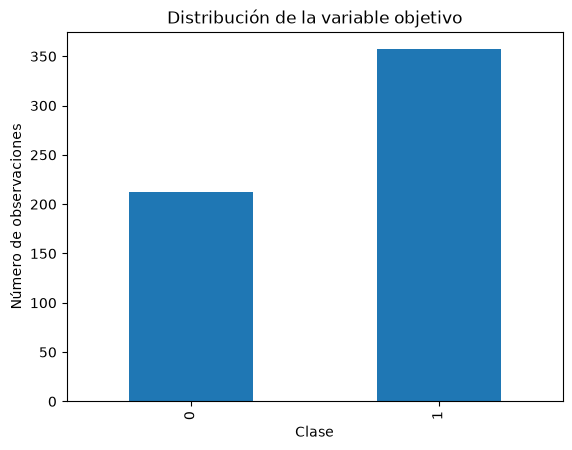

In [10]:
target_counts = y.value_counts().sort_index()

target_counts

target_distribution = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution

target_counts.plot(
    kind="bar",
    title="Distribución de la variable objetivo"
)

plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.show()

# 10. ¿Existe desbalance?

In [11]:
for target_class, percentage in target_distribution.items():
    print(f"Clase {target_class}: {percentage:.2f}%")

Clase 0: 37.26%
Clase 1: 62.74%


# 11. Estadísticos descriptivos

In [ ]:
description = X.describe().T

description["range"] = description["max"] - description["min"]

description[
    ["mean", "std", "min", "max", "range"]
].sort_values("range", ascending=False)

,mean,std,min,max,range
worst area,880.583128,569.356993,185.200000,4254.00000,4068.800000
mean area,654.889104,351.914129,143.500000,2501.00000,2357.500000
area error,40.337079,45.491006,6.802000,542.20000,535.398000
worst perimeter,107.261213,33.602542,50.410000,251.20000,200.790000
mean perimeter,91.969033,24.298981,43.790000,188.50000,144.710000
worst texture,25.677223,6.146258,12.020000,49.54000,37.520000
mean texture,19.289649,4.301036,9.710000,39.28000,29.570000
worst radius,16.269190,4.833242,7.930000,36.04000,28.110000
perimeter error,2.866059,2.021855,0.757000,21.98000,21.223000
mean radius,14.127292,3.524049,6.981000,28.11000,21.129000


# 12. Escalas de las variables

In [ ]:
scale_summary = pd.DataFrame({
    "mean": X.mean(),
    "std": X.std(),
    "min": X.min(),
    "max": X.max(),
})

scale_summary["range"] = (
    scale_summary["max"] - scale_summary["min"]
)

scale_summary.sort_values("range", ascending=False)

# Podemos comparar las variables con mayor y menor rango

largest_ranges = scale_summary.nlargest(5, "range")
smallest_ranges = scale_summary.nsmallest(5, "range")

print("Mayores rangos")
display(largest_ranges)

print("Menores rangos")
display(smallest_ranges)

Mayores rangos


,mean,std,min,max,range
worst area,880.583128,569.356993,185.200,4254.0,4068.800
mean area,654.889104,351.914129,143.500,2501.0,2357.500
area error,40.337079,45.491006,6.802,542.2,535.398
worst perimeter,107.261213,33.602542,50.410,251.2,200.790
mean perimeter,91.969033,24.298981,43.790,188.5,144.710


Menores rangos


,mean,std,min,max,range
fractal dimension error,0.003795,0.002646,0.000895,0.02984,0.028945
smoothness error,0.007041,0.003003,0.001713,0.03113,0.029417
mean fractal dimension,0.062798,0.007060,0.049960,0.09744,0.047480
concave points error,0.011796,0.006170,0.000000,0.05279,0.052790
symmetry error,0.020542,0.008266,0.007882,0.07895,0.071068


# 13. Distribuciones de algunas variables

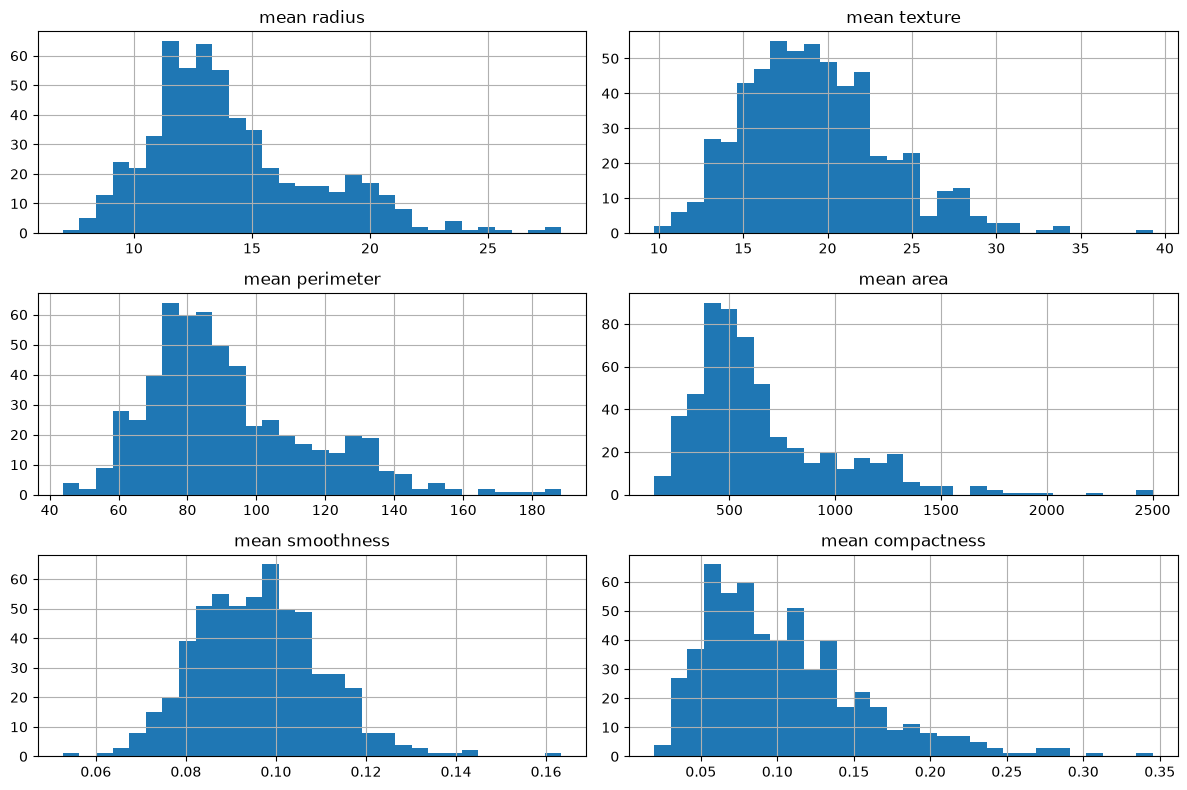

In [15]:
selected_features = list(X.columns[:6])

X[selected_features].hist(
    bins=30,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

# 14. Posibles valores extremos

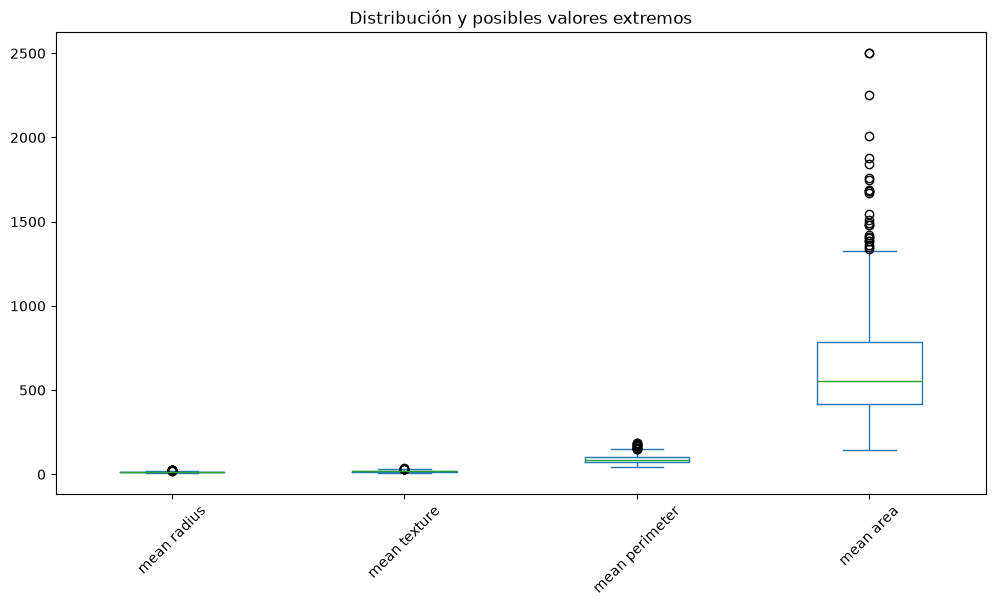

In [16]:
features_for_boxplot = selected_features[:4]

X[features_for_boxplot].plot(
    kind="box",
    figsize=(12, 6),
    rot=45
)

plt.title("Distribución y posibles valores extremos")
plt.show()

# 15. Correlaciones entre variables

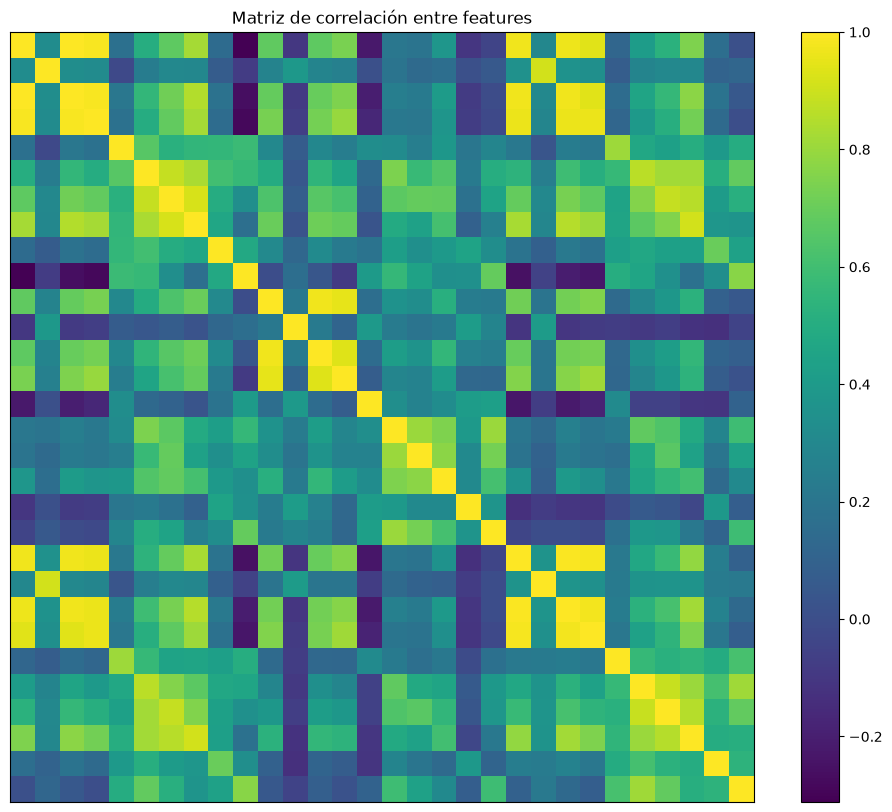

In [17]:
correlation = X.corr()

correlation

fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(
    correlation,
    aspect="auto"
)

ax.set_title("Matriz de correlación entre features")
ax.set_xticks([])
ax.set_yticks([])

fig.colorbar(image)
plt.show()

# 16. Pares con correlaciones fuertes

In [18]:
corr_abs = correlation.abs()

upper = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

strong_pairs = (
    upper.stack()
    .sort_values(ascending=False)
)

strong_pairs.head(15)

mean radius      mean perimeter     0.997855
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst perimeter  worst area         0.977578
radius error     perimeter error    0.972794
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
mean perimeter   worst radius       0.969476
mean radius      worst perimeter    0.965137
mean area        worst radius       0.962746
                 worst area         0.959213
                 worst perimeter    0.959120
radius error     area error         0.951830
dtype: float64

# 17. Relación de las features con el target

In [19]:
target_correlation = (
    df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

target_correlation.head(15)

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
mean compactness       -0.596534
worst compactness      -0.590998
radius error           -0.567134
perimeter error        -0.556141
area error             -0.548236
Name: target, dtype: float64

# 18. Comparar algunas variables entre clases

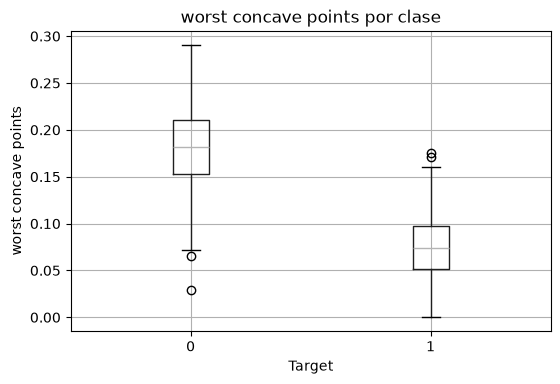

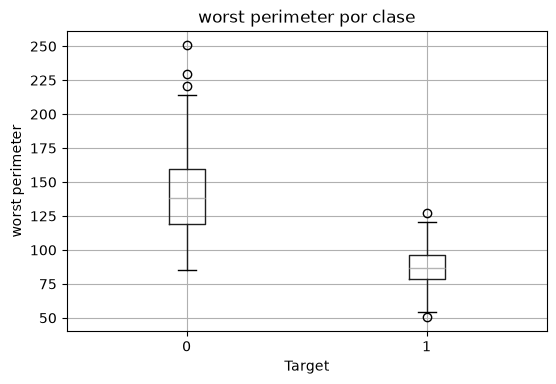

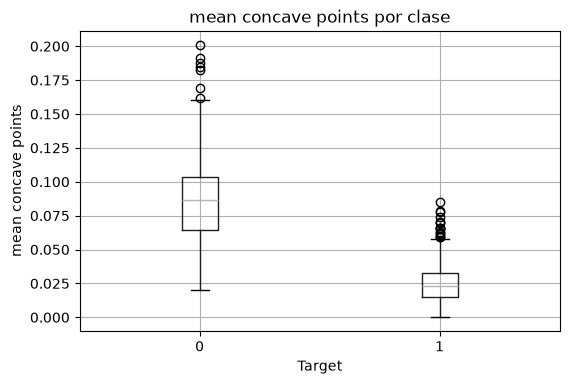

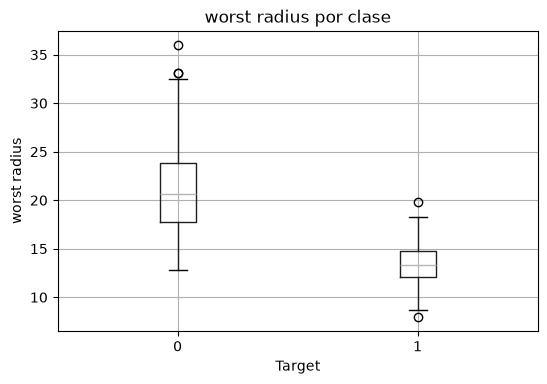

In [20]:
top_features = target_correlation.abs().nlargest(4).index.tolist()

for feature in top_features:
    df.boxplot(
        column=feature,
        by=TARGET,
        figsize=(6, 4)
    )

    plt.title(f"{feature} por clase")
    plt.suptitle("")
    plt.xlabel("Target")
    plt.ylabel(feature)
    plt.show()

# 19. Primeras consideraciones sobre métricas

Evaluar un futuro modelo:

- accuracy
- precision
- recall
- F1

# 20. Selección de la métrica definitiva

Preguntas metodológicas:

* ¿Qué clase consideramos positiva?
* ¿Qué representa un falso positivo?
* ¿Qué representa un falso negativo?
* ¿Cuál de esos errores es más importante?

# 21. ¿Qué modelo utilizar como baseline?

Una Logistic Regression resulta razonable como baseline porque:

- es rápida
- es relativamente sencilla
- funciona en clasificación binaria
- permite establecer una referencia

# 22. Conclusiones del EDA

### Naturaleza del problema

Estamos ante un problema supervisado de clasificación binaria.

El dataset contiene aproximadamente:

```text
569 observaciones
30 variables predictoras numéricas
1 variable objetivo
```

### Calidad de los datos

En el snapshot analizado:

```text
no se observaron valores faltantes significativos
no se observaron duplicados completos significativos
```

Por tanto no parece necesaria una limpieza agresiva.

### Target

Las clases no están perfectamente balanceadas, aunque tampoco presentan un desbalance extremo.

Esto aconseja no depender únicamente de `accuracy` y observar posteriormente métricas como:

```text
precision
recall
F1
```

### Escalas

Las features trabajan en magnitudes considerablemente diferentes.

Esto justifica considerar estandarización para algoritmos sensibles a escala.

### Correlaciones

Existen variables fuertemente relacionadas entre sí.

Esto puede generar redundancia y merece análisis posterior, pero no eliminaremos variables automáticamente durante el EDA.

### Baseline

Se propone comenzar con:

```text
SimpleImputer
↓
StandardScaler
↓
LogisticRegression
```

como baseline sencillo.

### Métrica

Utilizaremos inicialmente:

```text
F1
```

Esta decisión debe reevaluarse si el significado real del problema exige priorizar otro tipo de error.